<h1 style="color:magenta;">NSL - Exercises 04 </h1>

### 26/3/2026
### Giulia Federica Bianca Coppi (84486A)

## Ex 1

As requested, I implemented in `system.cpp` the algorithm to compute the Maxwell–Boltzmann distribution, $p(v^*,T^*)$, inside my Molecular Dynamics code by using data blocking to obtain single block averages, progressive average values and progressive uncertainties for $p(v^*,T^*)$.

The Maxwell–Boltzmann distribution, $p(v^*,T^*)$, can be approximately computed as a normalized histogram on an appropriate interval $\left[ 0, v_{max}\right]$ divided in an appropriate number of bins ($N_{bins}=30$) of constant width ($\Delta v =$ `_bin_size_v`). Therefore I computed 
$v_i = \sqrt{v_{x,i}^2 + v_{y,i}^2 + v_{z,i}^2}$
 for each particle and evaluated in which bin it fell by mapping the continuous velocity value onto the discrete grid via a floor operation (simulated through integer casting in C++):

$$bin=int(\frac{v_i}{\Delta v})$$



If the calculated index satisfies the boundary condition ($bin < N_{bins}$), the histogram is updated in memory by incrementing the respective property array element: 

```cpp
_measurement(_index_pofv + bin) += 1.0;

```

The histogram must be normalized so I divided each bin by the number of particles and the bin size. 

## Ex 2

I performed the MD simulations via a Lennard-Jones model (e.g. Argon parameters: $\sigma = 0.34$ nm, $\epsilon/k_B = 120$ K, $m=39.948$ amu) in the following conditions:
- gas phase: $\rho^\star = 0.05$, $T^\star \sim  2.0$ (cut-off radius: $r_c = 5.0$)

The simulation started from a very low entropic initial configuration:
1. initial **particle positions**: fcc crystal occupying half of the simulation box in each dimension
2. initial **velocity distribution**: $p_\delta(v^*,T^*) = \delta\left( v^* - v_{T^*}\right)$</span> where $v_{T^*}$ is suitably connected to $T^*$. This condition is obtained by imposing that every particle has an initial velocity $\pm v_{T^*}$ for only one of its velocity components: $v_x$, $v_y$, $v_z$.

For point 1 I divided by 2 the dimension of the box in `system.cpp` `read_configuration()`: for example for the first coordinate `_particle(i).setposition(0, this->pbc(_side(0)*x/2, 0));`

As shown in the following plot, the time evolution of the system triggers a rapid relaxation during which the velocity distribution approaches the expected equilibrium Maxwell–Boltzmann profile, yielding an effective temperature of $T^*_{\rm eff} = 1.32415$.This behavior perfectly matches the Second Principle of Thermodynamics: an isolated system naturally evolves toward a state of maximum entropy.

Regarding time-reversal symmetry, while the microscopic equations of motion solved by the Verlet integrator are strictly deterministic and reversible, macroscopically the system exhibits irreversible behavior on long timescales. Even if a perfect time-reversal transformation is performed, the exponential growth of micro instabilities driven by the finite numerical precision eventually destroys the phase-space correlation, causing the system to inevitably relax back toward the high-entropy disordered gas phase. This will be better discussed in the next exercise.

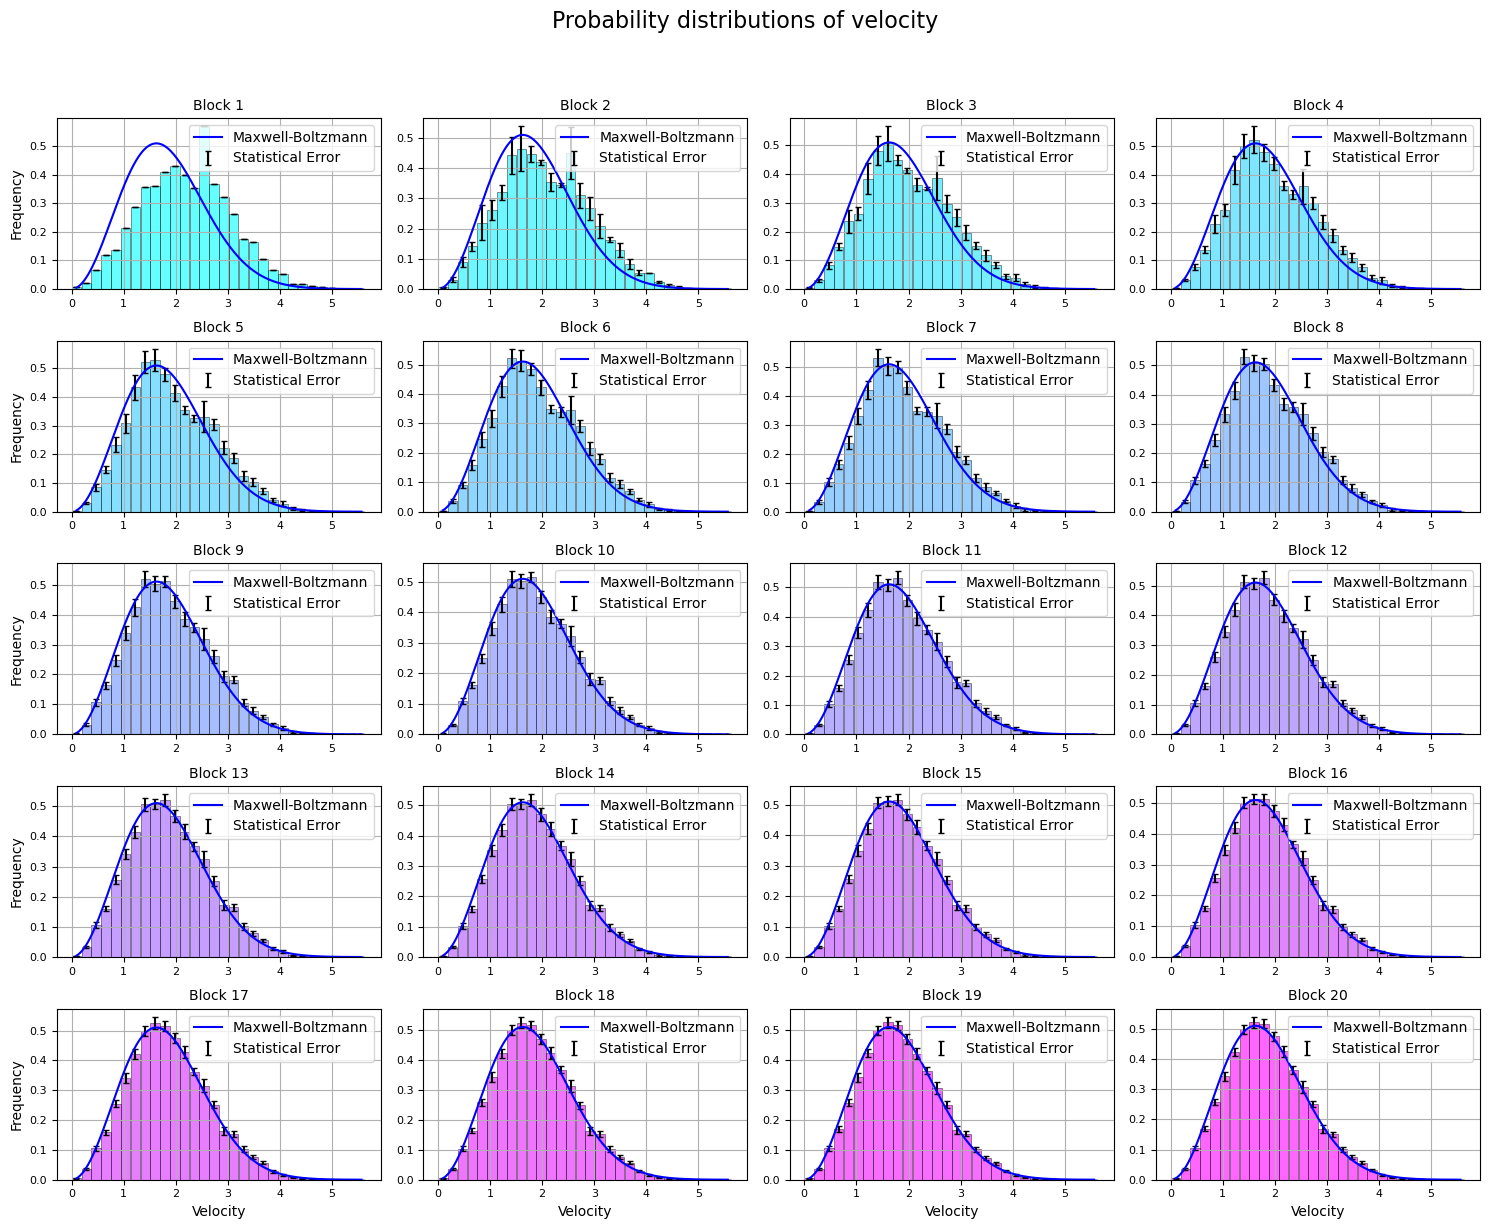

In [20]:
import matplotlib.pyplot as plt
import numpy as np

data = np.loadtxt("./nsl_simulator/NSL_SIMULATOR/DATA ANALYSIS/pofv.dat")

x = data[:, 0]   # velocity
y = data[:, 1]   # frequency, pofv average
err = data[:, 2] # progressive errors

T_eff = 1.32415

def maxwell_boltzmann(x):
    return 1/(2*np.pi*T_eff)**(3.0/2.0) * 4 * np.pi * x**2 * np.exp(-x**2 / (2 * T_eff))

colors = plt.cm.cool(np.linspace(0, 1, 20))  # colormap
block_size = 30
n_blocks = 20

fig, ax = plt.subplots(5, 4,figsize=(15, 12))
ax = ax.flatten()  # matrix -> arryay: iteration becomes easier

for i in range(n_blocks):
    start_idx = i * block_size
    end_idx = (i + 1) * block_size
    w = (x[end_idx-1] - x[start_idx]) / block_size

    ax[i].bar(x[start_idx:end_idx], y[start_idx:end_idx], width=w, bottom=None, align='center', color=colors[i], alpha=0.6, edgecolor='black', linewidth=0.5)
    ax[i].errorbar(x[start_idx:end_idx], y[start_idx:end_idx], yerr=err[start_idx:end_idx], fmt='none', ecolor='black', capsize=2, label='Statistical Error')
    
    ax[i].set_title(f'Block {i+1}', fontsize=10)
    ax[i].grid(True)
    ax[i].tick_params(labelsize=8)
    

    # axis labels on margins
    if i % 4 == 0:
        ax[i].set_ylabel('Frequency')
    if i >= 16:
        ax[i].set_xlabel('Velocity')

    velocity_fit = np.linspace(min(x), max(x), 300)
    ax[i].plot(velocity_fit, maxwell_boltzmann(velocity_fit), 'blue', label='Maxwell-Boltzmann')
    
    ax[i].legend()


plt.tight_layout()
plt.legend()
plt.suptitle('Probability distributions of velocity', fontsize=16, y=1.02)
plt.subplots_adjust(top=0.93)

plt.show()

## Ex 3

Starting from the final states of two MD simulations of the system in Exercise 04.2, one with $5\times 10^3$ time-steps the other with $5\times 10^4$ time-steps, by changing the direction of time, I tried to return back to the very low entropic initial configuration monitoring the behaviour of the **istantaneous** potential energy and temperature as a function of time going in both directions. 

To practically invert the direction of time at the end of the forward trajectory and initiate the backward propagation, I configured the system with `RESTART=1` and performed the following adjustments:

* **Velocity Inversion (Temperature):** I inverted the signs of all particle velocity components ($v \to -v$ inside the delta function distribution). This step ensures that the kinetic energy — and consequently the instantaneous temperature — is correctly tracked and evaluated during the backward run
* **Verlet Memory Inversion (Potential Energy):** since the standard Verlet integration scheme computes the future position $x(t+\Delta t)$ using only the current position $x(t)$, the previous position $x(t-\Delta t)$, and the current acceleration $a(t)$, it does not explicitly employ the velocity vector for spatial propagation. To mathematically force the integrator backward, I swapped the roles of the output configuration files when moving them into the `INPUT` directory: `/OUTPUT/config.xyz` was pasted to `/INPUT/conf-1.xyz` (acting as the "past"), while `/OUPUT/conf-1.xyz` was pasted to `/INPUT/config.xyz` (acting as the "present"). This effectively feeds the algorithm a backward-pointing initial displacement, forcing it to retrace its steps in configuration space

By comparing the two simulation lengths, this experiment highlights how finite numerical precision and chaotic dynamics (Lyapunov instability) impact predictability: the shorter simulation is expected to show high reversibility, whereas the longer one will inevitably drift away from the backward path due to the accumulation of approximation errors.


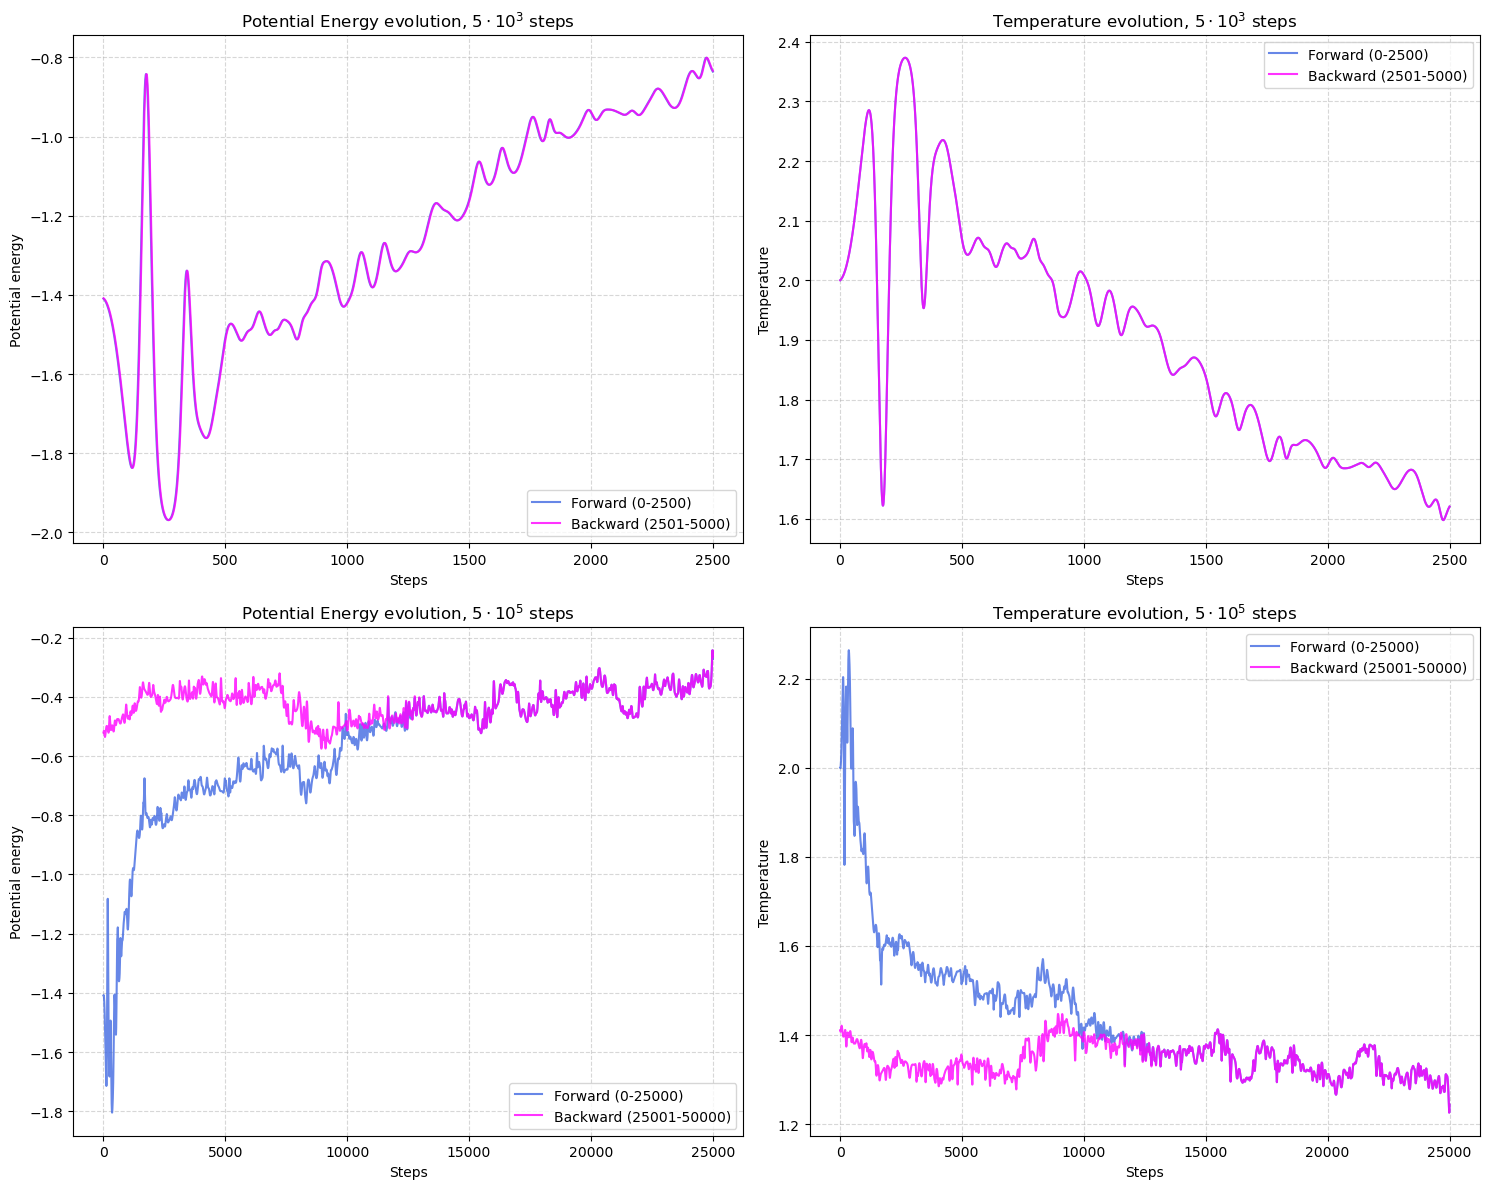

In [36]:
import matplotlib.pyplot as plt
import numpy as np

files = [
    "./nsl_simulator/NSL_SIMULATOR/DATA ANALYSIS/5_10_3_steps/Andata/potential_energy.dat",
    "./nsl_simulator/NSL_SIMULATOR/DATA ANALYSIS/5_10_3_steps/Ritorno/potential_energy.dat",
    "./nsl_simulator/NSL_SIMULATOR/DATA ANALYSIS/5_10_3_steps/Andata/temperature.dat",
    "./nsl_simulator/NSL_SIMULATOR/DATA ANALYSIS/5_10_3_steps/Ritorno/temperature.dat",
    "./nsl_simulator/NSL_SIMULATOR/DATA ANALYSIS/5_10_4_steps/Andata/potential_energy.dat",
    "./nsl_simulator/NSL_SIMULATOR/DATA ANALYSIS/5_10_4_steps/Ritorno/potential_energy.dat",
    "./nsl_simulator/NSL_SIMULATOR/DATA ANALYSIS/5_10_4_steps/Andata/temperature.dat",
    "./nsl_simulator/NSL_SIMULATOR/DATA ANALYSIS/5_10_4_steps/Ritorno/temperature.dat",
]

fig, axs = plt.subplots(2, 2, figsize=(15, 12))

#POTENTIAL ENERGY, SHORT SIMULATION

data_andata_pe_3=  np.loadtxt(files[0])
data_ritorno_pe_3=  np.loadtxt(files[1])

x_andata_pe_3 = data_andata_pe_3[:, 0] #step
y_andata_pe_3 = data_andata_pe_3[:, 1] #value

x_ritorno_pe_3 = data_ritorno_pe_3[:, 0] #step
y_ritorno_pe_3 = data_ritorno_pe_3[:, 1] #value
#data goes back in time
y_invert_pe_3 = data_ritorno_pe_3[:, 1][::-1]

axs[0, 0].plot(x_andata_pe_3, y_andata_pe_3, label="Forward (0-2500)", color='royalblue', alpha=0.8)
axs[0, 0].plot(x_ritorno_pe_3, y_invert_pe_3, label="Backward (2501-5000)", color='magenta', alpha=0.8)

axs[0, 0].set_title("Potential Energy evolution, $5 \cdot 10^3$ steps")
axs[0, 0].set_xlabel("Steps")
axs[0, 0].set_ylabel("Potential energy")
axs[0, 0].legend()
axs[0, 0].grid(True, linestyle='--', alpha=0.5)

#TEMPERATURE, SHORT SIMULATION

data_andata_T_3=  np.loadtxt(files[2])
data_ritorno_T_3=  np.loadtxt(files[3])

x_andata_T_3 = data_andata_T_3[:, 0] #step
y_andata_T_3 = data_andata_T_3[:, 1] #value

x_ritorno_T_3 = data_ritorno_T_3[:, 0] #step
y_ritorno_T_3 = data_ritorno_T_3[:, 1] #value
#data goes back in time
y_invert_T_3 = data_ritorno_T_3[:, 1][::-1]

axs[0, 1].plot(x_andata_T_3, y_andata_T_3, label="Forward (0-2500)", color='royalblue', alpha=0.8)
axs[0, 1].plot(x_ritorno_T_3, y_invert_T_3, label="Backward (2501-5000)", color='magenta', alpha=0.8)

axs[0, 1].set_title("Temperature evolution, $5 \cdot 10^3$ steps")
axs[0, 1].set_xlabel("Steps")
axs[0, 1].set_ylabel("Temperature")
axs[0, 1].legend()
axs[0, 1].grid(True, linestyle='--', alpha=0.5)

##POTENTIAL ENERGY, LONG SIMULATION

data_andata_pe_5=  np.loadtxt(files[4])
data_ritorno_pe_5=  np.loadtxt(files[5])

x_andata_pe_5 = data_andata_pe_5[:, 0] #step
y_andata_pe_5 = data_andata_pe_5[:, 1] #value

x_ritorno_pe_5 = data_ritorno_pe_5[:, 0] #step
y_ritorno_pe_5 = data_ritorno_pe_5[:, 1] #value
#data goes back in time
y_invert_pe_5 = data_ritorno_pe_5[:, 1][::-1]

axs[1, 0].plot(x_andata_pe_5, y_andata_pe_5, label="Forward (0-25000)", color='royalblue', alpha=0.8)
axs[1, 0].plot(x_ritorno_pe_5, y_invert_pe_5, label="Backward (25001-50000)", color='magenta', alpha=0.8)

axs[1, 0].set_title("Potential Energy evolution, $5 \cdot 10^5$ steps")
axs[1, 0].set_xlabel("Steps")
axs[1, 0].set_ylabel("Potential energy")
axs[1, 0].legend()
axs[1, 0].grid(True, linestyle='--', alpha=0.5)

#TEMPERATURE, LONG SIMULATION
data_andata_T_5=  np.loadtxt(files[6])
data_ritorno_T_5=  np.loadtxt(files[7])

x_andata_T_5 = data_andata_T_5[:, 0] #step
y_andata_T_5 = data_andata_T_5[:, 1] #value

x_ritorno_T_5 = data_ritorno_T_5[:, 0] #step
y_ritorno_T_5 = data_ritorno_T_5[:, 1] #value
#data goes back in time
y_invert_T_5 = data_ritorno_T_5[:, 1][::-1]

axs[1, 1].plot(x_andata_T_5, y_andata_T_5, label="Forward (0-25000)", color='royalblue', alpha=0.8)
axs[1, 1].plot(x_ritorno_T_5, y_invert_T_5, label="Backward (25001-50000)", color='magenta', alpha=0.8)

axs[1, 1].set_title("Temperature evolution, $5 \cdot 10^5$ steps")
axs[1, 1].set_xlabel("Steps")
axs[1, 1].set_ylabel("Temperature")
axs[1, 1].legend()
axs[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()